# Varying the alpha-fairness parameter

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_av_mat import plot_av_mat
from matplotlib import pyplot as plt
import os
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
folder='figures/alphaF_exp'
keyword = 'alphaF_exp'
main_folder = 'correlation_experiments_100rounds'



def fct_refine_res(res):
    res = res[["dataseed", "availability", "test_accuracy", "seed", "lr"]]

    # only look at the final accuracy:
    res.loc[:,['final_acc']] = res['test_accuracy'].apply(lambda x : x[-1])

    # take the best value accross learning rates:
    refined_res = res.groupby(['availability','dataseed', 'seed']).final_acc.apply(np.vstack).to_frame().reset_index()
    refined_res['final_best_acc'] = refined_res['final_acc'].apply(lambda x : x.max())

    refined_res = refined_res[['availability', 'final_best_acc', 'dataseed', 'seed']]

    # regroup all seeds results:
    refined_res = refined_res.groupby(['availability']).final_best_acc.apply(np.vstack).to_frame().reset_index() # regroup seeds results

    # compute the mean and std/3:
    refined_res['mean_acc'] = refined_res['final_best_acc'].apply(lambda x : x.mean())
    refined_res['std_3_acc'] = refined_res['final_best_acc'].apply(lambda x : x.std()/3)

    return(refined_res)

# Comparing Fine-tuning without fine-tuning

In [3]:
# seeds=["42", "78", "84"]

# cb_list = ["7cb", "8cb", "10cb"]
# lrs_list = [["5e-2", "1e-2"], ["5e-2", "1e-2"], ["5e-2", "1e-2"]]
# lab_list = ["$k=3.03$ kgCO2e - avg. 213 train. slots", "$k=1.98$ kgCO2e - avg. 178 train. slots", "$k=0.94$ kgCO2e - avg. 125 train. slots"]

# plt.figure(figsize=(10, 5))
# ax=plt.gca()

# for i in range(len(cb_list)):

#     cb = cb_list[i]
#     lrs = lrs_list[i]
#     lab = lab_list[i]
#     availabilities = f"alphaF50-alpha0.001-{cb} alphaF50-alpha0.01-{cb} alphaF50-alpha0.1-{cb} alphaF50-alpha0.5-{cb} alphaF50-alpha0.75-{cb} alphaF50-alpha0.9-{cb} alphaF50-alpha1.0-{cb}".split()

#     final_results = pd.DataFrame()

#     for ds_idx, ds in enumerate(["12345", "12346", "12347"]):

#         config = ExperimentConfig(
#             base_path=os.path.join("..", "logs"),
#             experiment="mnist_alphaF_var/dataseed_"+ds,
#             seeds=seeds,
#             algorithms=["fedavg"],
#             events=["global"],
#             lr_list=lrs,
#             alphas=["0.1"],
#             n_clients_list=["7"],
#             availabilities=availabilities,
#             n_rounds="50",
#             participations=["known"],
#             biased_list=["2"],
#             train_test="train",
#         )

#         raw_results = load_experiment_results(config)
#         raw_results['dataseed'] = ds
#         final_results = pd.concat([final_results, raw_results])

#     refined_res = fct_refine_res(final_results)
#     x_values = [float(a.replace('alphaF50-alpha','').replace(f"-{cb}", '')) for a in refined_res['availability']]
#     y = refined_res['mean_acc'] *100
#     y_upper = (refined_res['mean_acc']+ refined_res['std_3_acc']) *100
#     y_lower =  (refined_res['mean_acc']- refined_res['std_3_acc']) *100
#     colorblind_palette = sns.color_palette("colorblind")
#     plt.plot(x_values, y, '-o', label = lab, color=colorblind_palette[i % len(colorblind_palette)])
#     plt.xticks(fontsize=18)  # rotate x-axis labels to diagonal
#     plt.yticks(fontsize=18)  # rotate x-axis labels to diagonal
#     ax.fill_between(x_values, y_upper, y_lower, alpha=0.2)

# plt.xscale('log')
# plt.legend(fontsize=16)
# # plt.title('Final Mean Test Accuracy with Variance Band - 8cb')
# plt.grid()
# # ax.set_ylim([86, 100])
# plt.xlabel("Fairness parameter ($\\alpha$)", fontsize=18)
# plt.ylabel("Test Accuracy", fontsize=18)
# plt.savefig(folder+f"/alphaF_var-allcb.png", bbox_inches='tight')

Processing experiments: 100%|██████████| 2/2 [00:02<00:00,  1.31s/it]


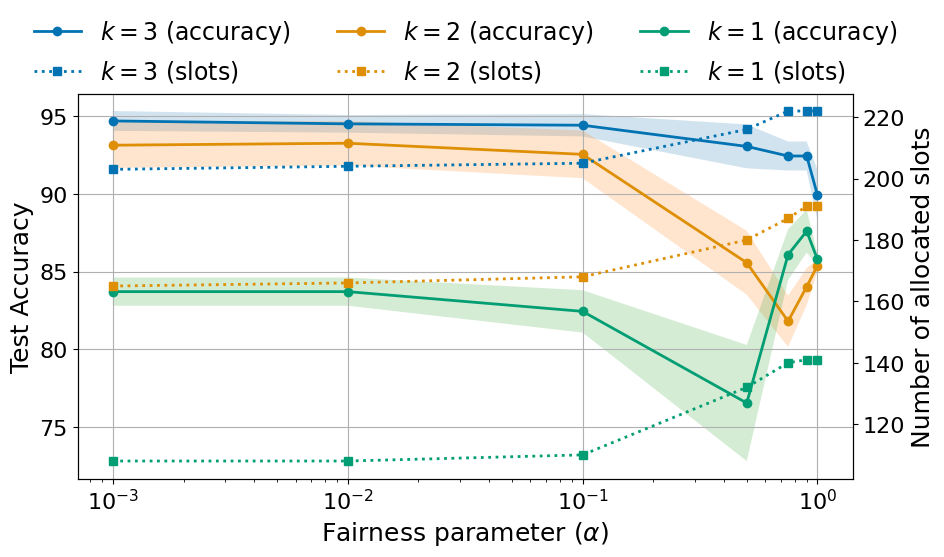

In [4]:
seeds=["42", "78", "84"]

cb_list = ["7cb", "8cb", "10cb"]
lrs_list = [["5e-2", "1e-2"], ["5e-2", "1e-2"], ["5e-2", "1e-2"]]
# lab_list = ["$k=3.03$ kgCO2e", "$k=1.98$ kgCO2e", "$k=0.94$ kgCO2e"]
lab_list = ["$k=3$", "$k=2$", "$k=1$"]


plt.figure(figsize=(10, 5))
ax=plt.gca()
ax2 = ax.twinx()

for i in range(len(cb_list)):

    cb = cb_list[i]
    lrs = lrs_list[i]
    lab = lab_list[i]
    availabilities = f"alphaF50-alpha0.001-{cb} alphaF50-alpha0.01-{cb} alphaF50-alpha0.1-{cb} alphaF50-alpha0.5-{cb} alphaF50-alpha0.75-{cb} alphaF50-alpha0.9-{cb} alphaF50-alpha1.0-{cb}".split()

    av_av = []
    for av_mat_name in availabilities:
        _path = "../availability_matrices/av-mat_"+av_mat_name+".csv"
        df = pd.DataFrame(pd.read_csv(_path, index_col=[0]))
        green=df.sum().sum()
        av_av.append(green)

    final_results = pd.DataFrame()

    for ds_idx, ds in enumerate(["12345", "12346", "12347"]):

        config = ExperimentConfig(
            base_path=os.path.join("..", "logs"),
            experiment="mnist_alphaF_var/dataseed_"+ds,
            seeds=seeds,
            algorithms=["fedavg"],
            events=["global"],
            lr_list=lrs,
            alphas=["0.1"],
            n_clients_list=["7"],
            availabilities=availabilities,
            n_rounds="50",
            participations=["known"],
            biased_list=["2"],
            train_test="train",
        )

        raw_results = load_experiment_results(config)
        raw_results['dataseed'] = ds
        final_results = pd.concat([final_results, raw_results])

    refined_res = fct_refine_res(final_results)
    x_values = [float(a.replace('alphaF50-alpha','').replace(f"-{cb}", '')) for a in refined_res['availability']]
    y = refined_res['mean_acc'] *100
    y_upper = (refined_res['mean_acc']+ refined_res['std_3_acc']) *100
    y_lower =  (refined_res['mean_acc']- refined_res['std_3_acc']) *100
    colorblind_palette = sns.color_palette("colorblind")
    ax.plot(x_values, y, '-o', label = lab+" (accuracy)", color=colorblind_palette[i % len(colorblind_palette)], markersize=6, linewidth=2)
    ax.fill_between(x_values, y_upper, y_lower, alpha=0.2)

    
    ax2.plot(x_values, av_av, ':s', label=lab + " (slots)", color=colorblind_palette[i % len(colorblind_palette)], markersize=6, linewidth=2)


ax.grid()
plt.xlabel("Fairness parameter ($\\alpha$)", fontsize=18)
ax.set_ylabel("Test Accuracy", fontsize=18)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)
ax.set_xscale('log')
ax.set_xlabel("Fairness parameter ($\\alpha$)", fontsize=18)
ax2.set_ylabel("Number of allocated slots", fontsize=18)


# Combine legends
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
tot_lines = [lines[0], lines2[0], lines[1], lines2[1], lines[2], lines2[2]]
tot_labels = [labels[0], labels2[0], labels[1], labels2[1], labels[2], labels2[2]]
ax2.legend(tot_lines, tot_labels, fontsize=17, bbox_to_anchor=(0.5, 1.25), ncol=3, loc='upper center', frameon=False)


# plt.show()
plt.savefig(folder+f"/alphaF_var-allcb.png", bbox_inches='tight', dpi=300)

## Av mat

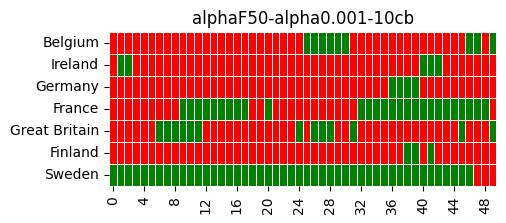

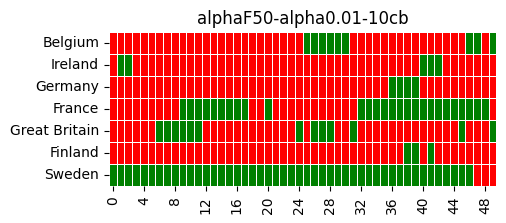

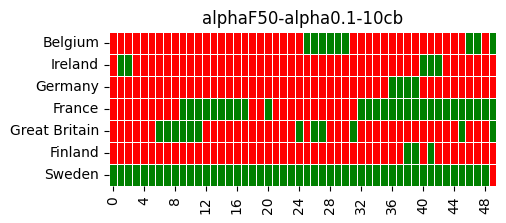

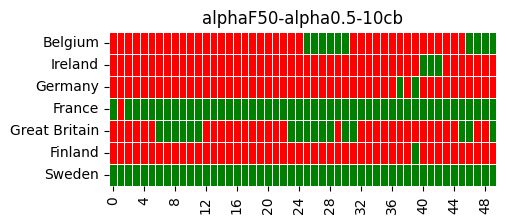

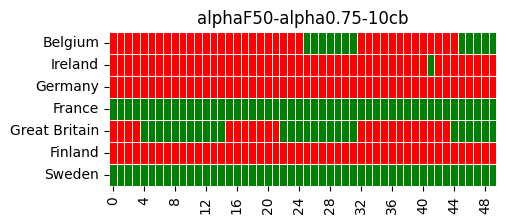

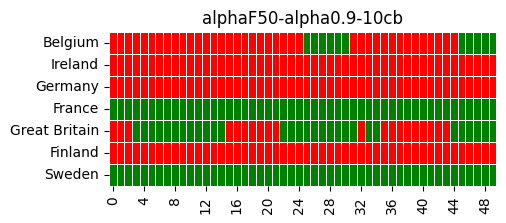

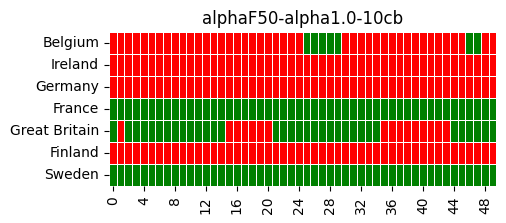

In [5]:
cb="10cb"
av_mat_list = f"alphaF50-alpha0.001-{cb} alphaF50-alpha0.01-{cb} alphaF50-alpha0.1-{cb} alphaF50-alpha0.5-{cb} alphaF50-alpha0.75-{cb} alphaF50-alpha0.9-{cb} alphaF50-alpha1.0-{cb}".split()
folder='alphaF_exp/av-mat'
for av_mat_name in av_mat_list:
    plot_av_mat(av_mat_name, folder)